# Fig 6: High TBT Variance Across a Long Decode

The next cell checks for `GPU_MON_ROOT/<MODEL_SHORT>/decode/64/vllm_core_log.jsonl` and runs
`profiling/decode_profile.py --batch-size 64` (GPU 0, ~10–15 min) to generate it if missing.

**Output:** `model_outputs/<MODEL_SHORT>/paper/section3/fig6/decode_step_drift.{pdf,png}`

### Call order
1. Data generation (auto, if needed)
2. `scripts/plot_decode_step_drift.py`

In [1]:
import subprocess
from pathlib import Path

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)


def run(cmd):
    buf = []
    with subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
    ) as proc:
        for line in proc.stdout:
            print(line, end="", flush=True)
            buf.append(line)
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed (exit {proc.returncode}): {' '.join(str(c) for c in cmd)}")
    return "".join(buf)

In [3]:
# Collect decode trace data. Skip if already present.
import sys
sys.path.insert(0, str(REPO_ROOT / "profiling"))
from config import GPU_MON_ROOT, MODEL_SHORT

data_file = GPU_MON_ROOT / MODEL_SHORT / "decode" / "64" / "vllm_core_log.jsonl"
if not data_file.exists():
    print(f"Data file not found: {data_file}")
    print("Running decode_profile.py --batch-size 64 (uses GPU 0, ~10-15 min)...")
    run([sys.executable, str(REPO_ROOT / "profiling" / "decode_profile.py"), "--batch-size", "64"])
else:
    print(f"Data file found: {data_file}")

Data file not found: /data/projects/eicchen/conserve_project/conserve/profiling/gpu_profiling/A40/Qwen3-0.6B/decode/64/vllm_core_log.jsonl
Running decode_profile.py --batch-size 64 (uses GPU 0, ~10-15 min)...
INFO 06-25 20:59:53 [__init__.py:216] Automatically detected platform cuda.
INFO 06-25 20:59:57 [utils.py:233] non-default args: {'trust_remote_code': True, 'download_dir': '/data/projects/eicchen/conserve_project/conserve/models', 'max_num_batched_tokens': 32768, 'max_num_seqs': 1024, 'disable_log_stats': True, 'rope_scaling': {'rope_type': 'dynamic', 'factor': 2.0}, 'enforce_eager': True}
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
INFO 06-25 20:59:58 [model.py:547] Resolved architecture: Qwen3ForCausalLM
`torch_dtype` is deprecated! Use `dtype` instead!
INFO 06-25 20:59:58 [model.py:1510] Using max model len 81920
INFO 06-25 20:59:58 [scheduler.py:205] Chunked prefill is enabled with max_num_batched_tokens=32768.
INFO 

Loaded 938,819 (request, step) latency rows from /data/projects/eicchen/conserve_project/conserve/profiling/gpu_profiling/A40/Qwen3-0.6B/decode/64/vllm_core_log.jsonl
Spread summary across step_ids:
  mean p5-p95 spread    = 2.919 ms
  mean p99              = 18.429 ms
  spread / median       = 17.9%
Central tendency (mean across step_ids):
  per-step mean   = 16.433 ms
  per-step median = 16.326 ms
  per-step gmean  = 16.414 ms

Saved /data/projects/eicchen/conserve_project/conserve/model_outputs/Qwen3-0.6B/paper/section3/fig6/decode_step_drift.pdf / .png
Linear fit on raw rows  (n = 227,406):
  intercept = 10.3316 ms
  slope     = 6.8828 us/step
  R^2       = 0.2891
Saved /data/projects/eicchen/conserve_project/conserve/model_outputs/Qwen3-0.6B/paper/section3/fig6/decode_step_drift_raw.pdf / .png


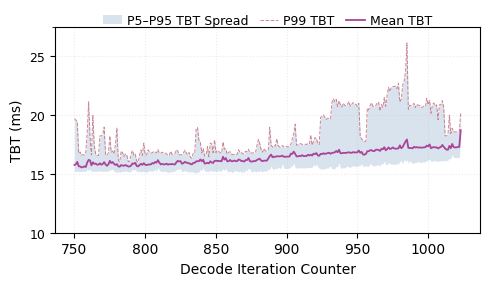

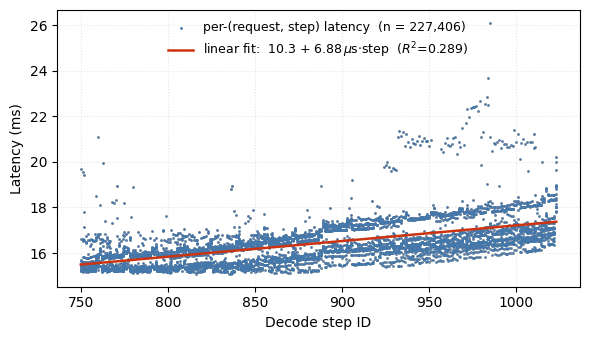

<Figure size 640x480 with 0 Axes>

In [1]:
%matplotlib inline
%run ../scripts/plot_decode_step_drift.py

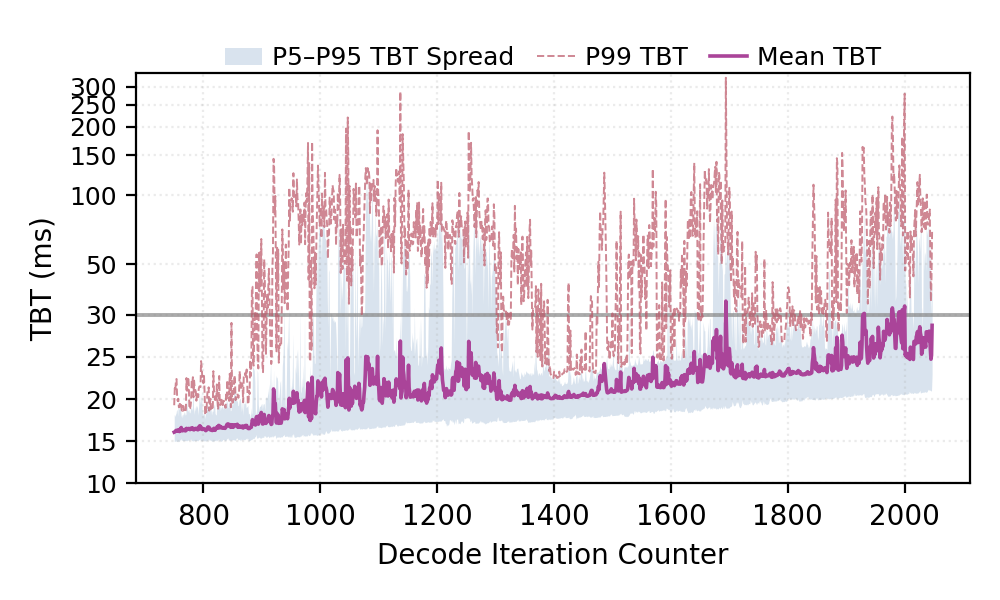

In [3]:
from IPython.display import Image
from pathlib import Path
import sys

REPO_ROOT = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / ".conserve_root").exists()
)
sys.path.insert(0, str(REPO_ROOT / "profiling"))
from config import MODEL_SHORT, MODEL_DATA_DIR

Image(str(MODEL_DATA_DIR / "paper" / "section3" / "fig6" / "decode_step_drift.png"))
Image(str("/data/projects/AgentScaling/conserve/paper/figures/section3/output/300W/decode_step_drift.png"))